# Mini GPT-2 From Scratch (Character Level Language Model)

This notebook builds a small version of GPT-2 completely from scratch, following the ideas from Andrej Karpathy's "build GPT from zero" style tutorials, to understand how transformers actually work internally.

**What this notebook does:**
1. Downloads a small text dataset (Tiny Shakespeare).
2. Tokenizes the text at character level (vocabulary = every unique character).
3. Builds a decoder-only transformer (same architecture family as GPT-2, just much smaller).
4. Trains the model to predict the next character.
5. Plots training/validation loss so we can check learning is actually happening.
6. Generates new text from the trained model.

**Dataset:** Tiny Shakespeare, downloaded automatically in the code below, no manual upload needed.

**Note on model size:** Real GPT-2 (small) has ~124-127M parameters and needs huge data + compute. Here the number of layers, heads and embedding size are reduced so it trains in a few minutes on a normal laptop/free notebook. The hyperparameters cell explains exactly how to scale this up to the full GPT-2 config if more compute is available (this is the bonus part).

**Improvements added on top of the basic version:**
- Weight tying between the token embedding and the output projection (this is what real GPT-2 does, and it reduces parameter count).
- GPT-2 style weight initialization (small random values, with extra scaling for the layers that write into the residual stream).
- Learning rate warmup + cosine decay schedule instead of a constant learning rate.
- Gradient clipping, to stop occasional large gradients from destabilizing training.
- Temperature and top-k sampling in text generation, instead of plain random sampling, so output quality can be tuned.


In [3]:
import torch
import torch.nn as nn
from torch.nn import functional as f
import matplotlib.pyplot as plt
import urllib.request
import os
import math


## Step 1: Downloading the Dataset

Tiny Shakespeare is downloaded directly from the internet so anyone running this notebook does not need to manually find and upload a file. It is Shakespeare's plays combined into a single text file, small enough to train on quickly, and a standard dataset for character-level language modelling.

In [4]:
data_url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
# link to the tiny shakespeare dataset, a small public dataset good for practicing language models
data_file = "input.txt"
# local filename the dataset will be saved as
if not os.path.exists(data_file):
    # only download if the file is not already on disk, so re-running this cell does not re-download every time
    urllib.request.urlretrieve(data_url, data_file)
    # fetches the file from the url and writes it to data_file
print("dataset downloaded and ready")
# confirms this step finished without errors


dataset downloaded and ready


In [5]:
with open(data_file, "r", encoding="utf-8") as file:
    # open the file in read mode, using utf-8 so all characters decode correctly
    text = file.read()
    # read the whole file into one big string

print("length of dataset in characters:", len(text))
# total number of characters, i.e. how big the dataset is
print(text[:300])
# preview the first 300 characters to see what the raw text looks like


length of dataset in characters: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us


## Step 2: Building the Vocabulary (Tokenizer)

For character-level tokenization, the vocabulary is simply every unique character that appears in the dataset (letters, punctuation, spaces, newlines). This is much simpler than the real GPT-2 tokenizer, which uses byte pair encoding (BPE), but it is a good starting point for understanding the core transformer logic without getting distracted by a complicated tokenizer.

In [6]:
all_characters = sorted(list(set(text)))
# set(text) collects every unique character, sorted() puts them in a fixed, repeatable order
vocab_size = len(all_characters)
# number of unique characters = size of the vocabulary
print("all the unique characters:", ''.join(all_characters))
# show the whole vocabulary as one string
print("vocab size:", vocab_size)
# total count of unique characters


all the unique characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
vocab size: 65


In [7]:
char_to_int = {}
# maps each character to a unique integer id
int_to_char = {}
# maps each integer id back to its character (needed to turn model output back into text)

for i, ch in enumerate(all_characters):
    # enumerate gives both the index and the character together
    char_to_int[ch] = i
    int_to_char[i] = ch

def encode(input_string):
    # turns a string into a list of integer token ids
    return [char_to_int[c] for c in input_string]

def decode(input_list):
    # turns a list of integer token ids back into a string
    return ''.join([int_to_char[i] for i in input_list])

print(encode("hello there"))
# quick check that encode() works
print(decode(encode("hello there")))
# quick check that encoding then decoding returns the original text


[46, 43, 50, 50, 53, 1, 58, 46, 43, 56, 43]
hello there


## Step 3: Preparing the Data for Training

The full text is converted to numbers with `encode`, then split into a training set and a validation set (90% / 10%). The validation set is never trained on directly -- it is only used to check whether the model is overfitting (memorizing) instead of learning general patterns.

In [8]:
full_data = torch.tensor(encode(text), dtype=torch.long)
# the whole dataset as one long tensor of token ids, torch.long because these are index values
print("shape of the full data tensor:", full_data.shape)
print("data type:", full_data.dtype)

split_point = int(0.9 * len(full_data))
# 90% of the data goes to training, the rest to validation
train_data = full_data[:split_point]
val_data = full_data[split_point:]
print("training data size:", len(train_data))
print("validation data size:", len(val_data))


shape of the full data tensor: torch.Size([1115394])
data type: torch.int64
training data size: 1003854
validation data size: 111540


## Step 4: Setting the Hyperparameters

These settings control the size and training behaviour of the model. They are kept small on purpose so the model trains quickly on a normal machine or a free GPU notebook.

**Bonus note (scaling to full GPT-2):** the real GPT-2 (small) uses `embed_size=768`, `num_heads=12`, `num_layers=12`, `context_size=1024`, giving around 124-127M parameters. To move towards that, the values below would just need to change to those numbers, together with a switch from character-level tokenization to a proper subword tokenizer (BPE / tiktoken). A commented-out config for this is included below for reference -- it is not run here because it would need a much more powerful GPU and a lot more training time.

In [9]:
batch_size = 32
# number of sequences processed together in one training step (bigger = more memory, more stable gradients)
context_size = 64
# maximum number of previous characters the model can look at when predicting the next one (a.k.a. block_size)
embed_size = 128
# size of the vector used to represent each character/token inside the model
num_heads = 4
# number of attention heads in multi-head self-attention; more heads = more parallel "views" of the sequence
num_layers = 4
# number of transformer blocks stacked on top of each other
dropout_rate = 0.1
# fraction of neurons randomly disabled during training, helps prevent overfitting
learning_rate = 3e-4
# base (peak) learning rate used by the optimizer
warmup_iters = 100
# number of steps over which the learning rate ramps up from 0 to the peak value, this stabilizes early training
max_iters = 3000
# total number of training iterations
eval_interval = 300
# how often (in steps) to evaluate and print the current loss
eval_iters = 100
# number of batches averaged over when estimating loss, this makes the reported number less noisy
grad_clip = 1.0
# maximum allowed gradient norm; gradients larger than this get scaled down, which avoids occasional unstable updates
device = "cuda" if torch.cuda.is_available() else "cpu"
# use the gpu automatically if one is available, otherwise fall back to cpu
torch.manual_seed(1337)
# fixed random seed so results are reproducible across runs
print("using device:", device)

# ---- reference only: the real GPT-2 (small) config, not executed here ----
# full_gpt2_config = dict(
#     context_size=1024,
#     embed_size=768,
#     num_heads=12,
#     num_layers=12,
#     dropout_rate=0.1,
# )
# switching to this config (plus a BPE tokenizer) gets close to the real ~124-127M parameter GPT-2.


using device: cuda


## Step 5: Creating Batches of Data

The dataset is one long sequence of numbers, so a function is needed that randomly samples small chunks of length `context_size` for training. For every input chunk `x`, the target `y` is the same chunk shifted one position to the right, because the model's job is to predict the next character given the previous ones.

In [10]:
def get_batch(split):
    # returns one batch of (input, target) pairs; split chooses "train" or "val" data
    data = train_data if split == "train" else val_data
    random_start_points = torch.randint(len(data) - context_size, (batch_size,))
    # pick batch_size random starting positions inside the chosen dataset
    x = torch.stack([data[i:i + context_size] for i in random_start_points])
    # input = a context_size-long chunk starting at each random position
    y = torch.stack([data[i + 1:i + context_size + 1] for i in random_start_points])
    # target = the same chunk shifted one step to the right (next-character prediction)
    x, y = x.to(device), y.to(device)
    return x, y

xb, yb = get_batch("train")
# quick sanity check on shapes
print("input batch shape:", xb.shape)
print("target batch shape:", yb.shape)


input batch shape: torch.Size([32, 64])
target batch shape: torch.Size([32, 64])


## Step 6: Building One Self-Attention Head

This is the core building block of a transformer. Self-attention lets every position in the sequence "look at" earlier positions and decide which ones matter for predicting the next character. This uses masked (causal) self-attention: a position can only look at positions before it, never after, since this is a decoder-only model like GPT.

In [11]:
class Head(nn.Module):
    # a single attention head; several of these get combined into multi-head attention
    def __init__(self, head_size):
        # head_size = dimensionality of the key/query/value vectors for this head
        super().__init__()
        self.key = nn.Linear(embed_size, head_size, bias=False)
        # projects the input embedding into a "key" vector
        self.query = nn.Linear(embed_size, head_size, bias=False)
        # projects the input embedding into a "query" vector
        self.value = nn.Linear(embed_size, head_size, bias=False)
        # projects the input embedding into a "value" vector
        self.register_buffer("tril", torch.tril(torch.ones(context_size, context_size)))
        # lower-triangular matrix of ones, used as a mask so a position cannot see future positions (causal attention)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        batch, time, channels = x.shape
        # batch = number of sequences, time = sequence length, channels = embedding size
        k = self.key(x)
        q = self.query(x)
        weights = q @ k.transpose(-2, -1) * (channels ** -0.5)
        # attention scores: query dotted with key, scaled down to keep values in a stable range
        weights = weights.masked_fill(self.tril[:time, :time] == 0, float("-inf"))
        # hide future positions by setting their score to -inf, so softmax turns them into 0
        weights = f.softmax(weights, dim=-1)
        # turn the scores into probabilities that sum to 1 across each row
        weights = self.dropout(weights)
        v = self.value(x)
        output = weights @ v
        # combine the value vectors, weighted by how much attention each position gets
        return output


## Step 7: Building Multi-Head Attention

Instead of one attention head, GPT uses several heads running in parallel, each free to learn a different kind of pattern (e.g. one head might track grammar, another longer-range dependencies). Their outputs are joined together and passed through one more linear layer.

In [12]:
class MultiHeadAttention(nn.Module):
    # combines several attention heads into one module
    def __init__(self, num_heads, head_size):
        super().__init__()
        self.heads = nn.ModuleList([Head(head_size) for _ in range(num_heads)])
        # a list of independent attention heads; ModuleList makes sure pytorch tracks all their parameters
        self.projection = nn.Linear(head_size * num_heads, embed_size)
        # combines the concatenated head outputs back into the original embedding size
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x):
        output = torch.cat([h(x) for h in self.heads], dim=-1)
        # run the input through every head separately, then place their outputs side by side
        output = self.dropout(self.projection(output))
        return output


## Step 8: Building the Feed-Forward Network

After attention, GPT passes the data through a small feed-forward network applied independently at each position. This gives the model extra capacity to process the information gathered by attention.

In [13]:
class FeedForward(nn.Module):
    # a simple two-layer network used inside each transformer block
    def __init__(self, embed_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(embed_size, 4 * embed_size),
            # expand to 4x the embedding size, matching the ratio used in the original transformer paper
            nn.ReLU(),
            # non-linearity, lets the model learn more than just straight-line relationships
            nn.Linear(4 * embed_size, embed_size),
            # project back down to the original embedding size
            nn.Dropout(dropout_rate),
        )

    def forward(self, x):
        return self.net(x)


## Step 9: Building One Transformer Block

A transformer block combines multi-head attention and the feed-forward network, along with layer normalization and residual (skip) connections. Residual connections help gradients flow through deep networks, and layer normalization keeps activations stable -- both are important for training to actually converge.

In [14]:
class Block(nn.Module):
    # one full transformer block; GPT stacks many of these on top of each other
    def __init__(self, embed_size, num_heads):
        super().__init__()
        head_size = embed_size // num_heads
        # split the embedding size evenly across the attention heads
        self.self_attention = MultiHeadAttention(num_heads, head_size)
        self.feed_forward = FeedForward(embed_size)
        self.layer_norm1 = nn.LayerNorm(embed_size)
        # normalizes the input before attention (pre-norm), which makes training more stable
        self.layer_norm2 = nn.LayerNorm(embed_size)
        # normalizes the input before the feed-forward step

    def forward(self, x):
        x = x + self.self_attention(self.layer_norm1(x))
        # residual connection: add the attention output back onto the input
        x = x + self.feed_forward(self.layer_norm2(x))
        # residual connection: add the feed-forward output back onto the input
        return x


## Step 10: Building the Full GPT Model

Everything comes together here:
- A token embedding table (turns character ids into vectors).
- A position embedding table (tells the model where each character sits in the sequence, since attention alone has no sense of order).
- Several stacked transformer blocks.
- A final layer normalization.
- A final linear layer turning the internal representation into a score (logit) for every character in the vocabulary.

Two extra things are added here compared to the most basic version:
- **Weight tying:** the output layer reuses the same weight matrix as the token embedding table. This is what the real GPT-2 does -- it saves parameters and tends to improve generalization, since "understanding" a token and "predicting" a token are related jobs.
- **Custom weight initialization:** weights start from a small normal distribution (like GPT-2), and the projection layers that feed into the residual stream get an extra scaling factor so that activations do not grow too large as more layers are stacked.

A `generate` method is also included so the trained model can produce new text, with temperature and top-k controls to adjust how random or focused the output is.

In [15]:
class GPTLanguageModel(nn.Module):
    # the main model: a small decoder-only transformer, similar in design to gpt-2
    def __init__(self):
        super().__init__()
        self.token_embedding_table = nn.Embedding(vocab_size, embed_size)
        # turns each character id into a vector of size embed_size
        self.position_embedding_table = nn.Embedding(context_size, embed_size)
        # gives every position in the sequence its own vector, so the model knows character order
        self.blocks = nn.Sequential(*[Block(embed_size, num_heads) for _ in range(num_layers)])
        # stack num_layers transformer blocks one after another
        self.final_layer_norm = nn.LayerNorm(embed_size)
        self.output_head = nn.Linear(embed_size, vocab_size)
        # turns the model's internal representation into a score for every character in the vocabulary

        self.output_head.weight = self.token_embedding_table.weight
        # weight tying: reuse the token embedding weights for the output layer, exactly as real GPT-2 does

        self.apply(self._init_weights)
        # apply gpt-2 style initialization to every layer in the model

        for name, param in self.named_parameters():
            if name.endswith("projection.weight") or name.endswith("net.2.weight"):
                # these are the layers that write directly into the residual stream
                # (the attention output projection, and the second linear layer in feed-forward)
                # scaling them down keeps the residual stream from growing too large as layers stack up
                nn.init.normal_(param, mean=0.0, std=0.02 / math.sqrt(2 * num_layers))

    def _init_weights(self, module):
        # gpt-2 style initialization: small random weights, zero biases, normal embeddings
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, index, targets=None):
        # index: batch of input token ids, targets: optional, only used to compute the training loss
        batch, time = index.shape
        token_embeddings = self.token_embedding_table(index)
        # embedding vector for every token id in the input
        position_embeddings = self.position_embedding_table(torch.arange(time, device=device))
        # embedding vector for every position from 0 to time-1
        x = token_embeddings + position_embeddings
        # combine token identity and position information
        x = self.blocks(x)
        x = self.final_layer_norm(x)
        logits = self.output_head(x)
        # a score for every character in the vocabulary, at every position

        if targets is None:
            loss = None
            # no targets means we only want predictions, not a loss value
        else:
            batch, time, channels = logits.shape
            logits = logits.view(batch * time, channels)
            # cross entropy expects a 2d tensor of (num_predictions, num_classes)
            targets = targets.view(batch * time)
            loss = f.cross_entropy(logits, targets)
            # measures how far the predicted probabilities are from the actual next character
        return logits, loss

    @torch.no_grad()
    def generate(self, index, max_new_tokens, temperature=1.0, top_k=None):
        # generates new text one character at a time
        # index: starting sequence of token ids, max_new_tokens: how many new characters to create
        # temperature: >1 makes output more random/creative, <1 makes it more conservative/predictable
        # top_k: if set, only sample from the k most likely characters at each step (cuts out unlikely, noisy choices)
        was_training = self.training
        self.eval()
        # turn off dropout during generation so predictions are not affected by random noise

        for _ in range(max_new_tokens):
            index_cropped = index[:, -context_size:]
            # the model can only look back context_size characters, so crop anything older
            logits, _ = self(index_cropped)
            logits = logits[:, -1, :]
            # only the prediction for the very next character is needed
            logits = logits / temperature
            # scale the logits: higher temperature flattens the distribution (more random), lower sharpens it

            if top_k is not None:
                top_values, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                # find the score of the k-th most likely character
                logits[logits < top_values[:, [-1]]] = float("-inf")
                # mask out every character outside the top-k, so it cannot be sampled

            probabilities = f.softmax(logits, dim=-1)
            next_index = torch.multinomial(probabilities, num_samples=1)
            # sample the next character according to the (possibly filtered) probabilities
            index = torch.cat((index, next_index), dim=1)
            # append the new character so it can be used as context for the next step

        if was_training:
            self.train()
            # restore training mode if generation was called mid-training
        return index


In [16]:
model = GPTLanguageModel()
model = model.to(device)
total_params = sum(p.numel() for p in model.parameters())
# add up the number of elements in every parameter tensor
print("total parameters in mini gpt model:", total_params)
# compare this to the ~127 million parameters in real GPT-2 (small)


total parameters in mini gpt model: 808385


## Step 11: Estimating Loss

Checking the loss on just one batch is noisy, since batches are random. This function averages the loss over several batches for both train and validation splits, giving a much smoother, more reliable number to track.

In [17]:
@torch.no_grad()
# no gradients are needed here since this is only evaluation, not training -- saves memory and time
def estimate_loss():
    output = {}
    model.eval()
    # turn off dropout so the loss estimate is stable
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            x, y = get_batch(split)
            logits, loss = model(x, y)
            losses[k] = loss.item()
        output[split] = losses.mean()
        # average over eval_iters batches to reduce noise
    model.train()
    # switch back to training mode so dropout is active again
    return output


## Step 12: Training the Model

The model is trained with the AdamW optimizer, a standard and reliable choice for transformers. On top of the basic loop, this version adds:
- **Learning rate warmup + cosine decay:** the learning rate ramps up linearly for the first `warmup_iters` steps, then decays smoothly following a cosine curve down to a small fraction of the peak. This is the schedule real GPT-2 style training uses, and it tends to train more stably than a constant learning rate.
- **Gradient clipping:** gradients are clipped to a maximum norm before each optimizer step, which prevents rare, unusually large gradients from throwing training off course.

Loss values are recorded at every evaluation step so they can be plotted afterwards.

In [18]:
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
# adamw is a common, reliable choice for training transformer models


def get_lr(step):
    # returns the learning rate to use at a given training step
    if step < warmup_iters:
        return learning_rate * (step + 1) / warmup_iters
        # linear warmup: ramp up from 0 to the peak learning rate
    progress = (step - warmup_iters) / max(1, (max_iters - warmup_iters))
    cosine_decay = 0.5 * (1 + math.cos(math.pi * progress))
    # cosine curve smoothly decays the learning rate towards the end of training
    min_lr_ratio = 0.1
    # never let the learning rate decay below 10% of its peak value
    return learning_rate * (min_lr_ratio + (1 - min_lr_ratio) * cosine_decay)


train_loss_history = []
val_loss_history = []
steps_recorded = []

for step in range(max_iters):
    current_lr = get_lr(step)
    for param_group in optimizer.param_groups:
        param_group["lr"] = current_lr
    # update the optimizer's learning rate for this step according to the warmup/decay schedule

    if step % eval_interval == 0 or step == max_iters - 1:
        losses = estimate_loss()
        print(f"step {step}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}, lr {current_lr:.6f}")
        train_loss_history.append(losses['train'].item())
        val_loss_history.append(losses['val'].item())
        steps_recorded.append(step)

    xb, yb = get_batch("train")
    logits, loss = model(xb, yb)
    optimizer.zero_grad(set_to_none=True)
    # clear old gradients before computing new ones
    loss.backward()
    # backpropagation: compute gradients from the current loss
    torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
    # cap the gradient norm so a single bad batch cannot cause a huge, destabilizing weight update
    optimizer.step()
    # update the model weights using the (clipped) gradients

print("training finished")


step 0: train loss 4.2235, val loss 4.2248, lr 0.000003
step 300: train loss 2.3851, val loss 2.3847, lr 0.000297
step 600: train loss 2.1714, val loss 2.1953, lr 0.000281
step 900: train loss 1.9968, val loss 2.0481, lr 0.000252
step 1200: train loss 1.8713, val loss 1.9628, lr 0.000215
step 1500: train loss 1.7941, val loss 1.9210, lr 0.000172
step 1800: train loss 1.7302, val loss 1.8585, lr 0.000129
step 2100: train loss 1.6902, val loss 1.8369, lr 0.000089
step 2400: train loss 1.6607, val loss 1.8125, lr 0.000058
step 2700: train loss 1.6446, val loss 1.7958, lr 0.000037
step 2999: train loss 1.6336, val loss 1.7831, lr 0.000030
training finished


## Step 13: Visualizing the Training Progress

Plotting training and validation loss shows whether the model is learning properly, and whether it is overfitting (which would show up as validation loss rising while training loss keeps falling).

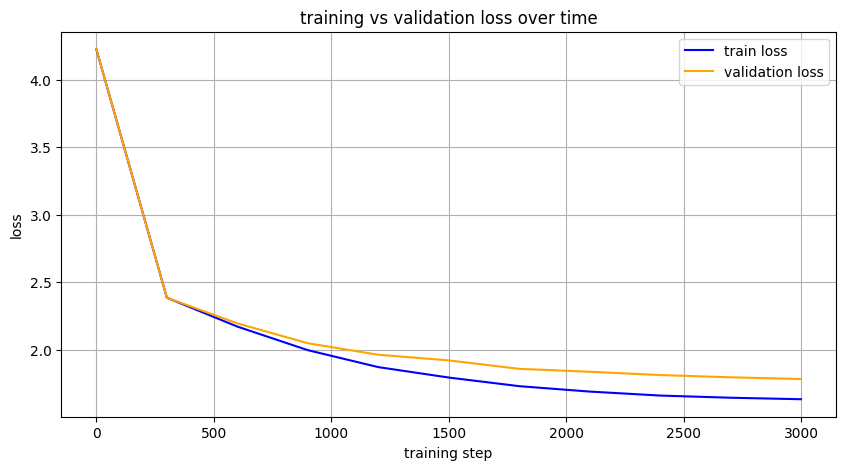

In [24]:
plt.figure(figsize=(10, 5))
plt.plot(steps_recorded, train_loss_history, label="train loss", color="blue")
plt.plot(steps_recorded, val_loss_history, label="validation loss", color="orange")
plt.xlabel("training step")
plt.ylabel("loss")
plt.title("training vs validation loss over time")
plt.legend()
plt.grid(True)
plt.show()


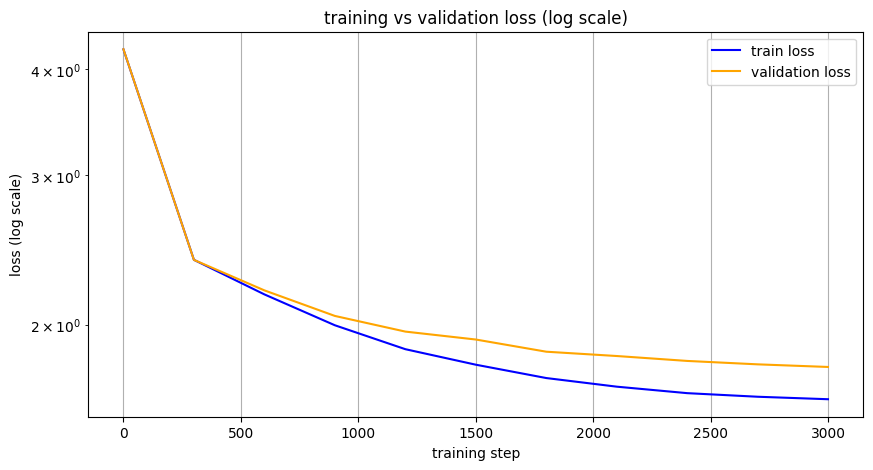

In [25]:
plt.figure(figsize=(10, 5))
# same plot, but on a log scale for the y axis, which makes small improvements later in training easier to see
plt.plot(steps_recorded, train_loss_history, label="train loss", color="blue")
plt.plot(steps_recorded, val_loss_history, label="validation loss", color="orange")
plt.yscale("log")
plt.xlabel("training step")
plt.ylabel("loss (log scale)")
plt.title("training vs validation loss (log scale)")
plt.legend()
plt.grid(True)
plt.show()


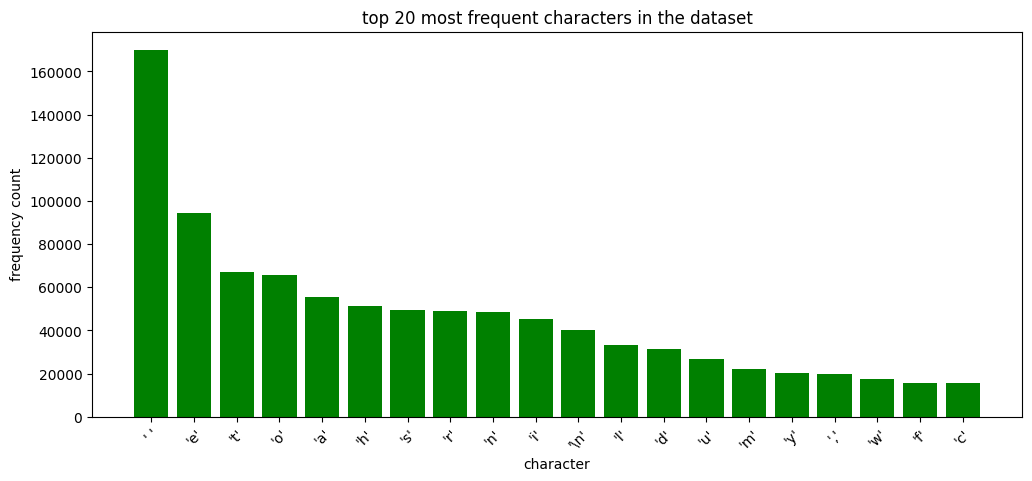

In [26]:
char_counts = {}
# count how many times each character appears in the dataset
for ch in text:
    if ch in char_counts:
        char_counts[ch] = char_counts[ch] + 1
    else:
        char_counts[ch] = 1

sorted_chars = sorted(char_counts.items(), key=lambda item: item[1], reverse=True)[:20]
# sort characters by frequency, descending, keep the top 20
top_chars = [repr(item[0]) for item in sorted_chars]
# repr() so special characters like newline show up clearly on the chart
top_counts = [item[1] for item in sorted_chars]

plt.figure(figsize=(12, 5))
plt.bar(top_chars, top_counts, color="green")
plt.xlabel("character")
plt.ylabel("frequency count")
plt.title("top 20 most frequent characters in the dataset")
plt.xticks(rotation=45)
plt.show()


## Step 14: Generating Text From the Trained Model

Now the trained model generates brand new text, character by character, starting from a blank input. Since this is a small model trained on a limited dataset for a short time, the output will not be perfect English, but it should show word-like structures, punctuation, and Shakespeare-style formatting (character names followed by colons, line breaks, etc.), which shows the model has genuinely learned patterns from the data rather than just memorizing.

`temperature` and `top_k` can be adjusted below: lower temperature / smaller top_k gives more conservative, repetitive text; higher temperature / larger (or no) top_k gives more varied but potentially less coherent text.

In [27]:
starting_input = torch.zeros((1, 1), dtype=torch.long, device=device)
# start generation from a single blank token
generated_output = model.generate(starting_input, max_new_tokens=500, temperature=0.8, top_k=20)
# generate 500 new characters, sampling only from the 20 most likely options at each step
generated_text = decode(generated_output[0].tolist())
print(generated_text)



Rown than the have mOusing stand it;
And detering the corces heating not of long
Breath in prover shall brother honk hyou.

MENENIUS:
If I lonk you had sistand in of my sleep me.

KING RICHARD III:
Are think to me with was should not seet to speak
And with pround by felow than he prience
That I will it rebelant the king:
And an her the should onse will the friends
And thy precution, and it, for last; and with the courd day
Will to make and welch them and bon panger the lack,
And well with elst h


## Step 15: Saving the Trained Model

The trained weights are saved to a file so the model can be reloaded later without retraining from scratch.

In [28]:
torch.save(model.state_dict(), "mini_gpt_model.pth")
# save only the weights (state dictionary), not the whole python object
print("model saved successfully as mini_gpt_model.pth")


model saved successfully as mini_gpt_model.pth


## Conclusion and What This Covers

This notebook builds a decoder-only transformer language model completely from scratch, without any pre-built GPT libraries. It implements:
- Character-level tokenization (encode/decode).
- Token and position embeddings.
- Masked (causal) self-attention from scratch, so the model cannot cheat by looking at future characters.
- Multi-head attention, feed-forward layers, residual connections and layer normalization -- the same architecture family as real GPT-2, just much smaller.
- GPT-2 style weight tying and weight initialization.
- A full training loop with a learning-rate warmup + cosine decay schedule, gradient clipping, loss tracking and evaluation.
- Text generation with temperature and top-k sampling.

**Parameter comparison:** this model uses only a small fraction of the ~127 million parameters in real GPT-2 (small), because `embed_size`, `num_heads`, `num_layers` and `context_size` are all reduced. That was done on purpose so training finishes in a reasonable time without a very powerful GPU.

**Further bonus directions to explore:**
- Train on a non-English or multilingual dataset (e.g. Hindi or Hinglish text) to see how the model adapts to a different script/language.
- Replace character-level tokenization with a proper subword tokenizer (Byte Pair Encoding / tiktoken), which is what real GPT-2 uses.
- Increase `embed_size`, `num_heads`, `num_layers` and `context_size` towards the real 127M parameter GPT-2 configuration, given more compute.
- Try different attention mechanisms, such as sliding window attention or rotary positional embeddings (RoPE), instead of the simple learned position embeddings used here.
- Mixed-precision training (`torch.autocast`) and a larger batch size, to make better use of a GPU if one is available.